In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [34]:
df = pd.read_csv("data/Foreign_Exchange_Rates.xls")

df.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [44]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nDataset info:")
print(df.info())

df.head()

Dataset shape: (5217, 25)

Column names:
Index(['Date', 'Time Serie', 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
       'EURO AREA - EURO/US$', 'NEW ZEALAND - NEW ZELAND DOLLAR/US$',
       'UNITED KINGDOM - UNITED KINGDOM POUND/US$', 'BRAZIL - REAL/US$',
       'CANADA - CANADIAN DOLLAR/US$', 'CHINA - YUAN/US$',
       'HONG KONG - HONG KONG DOLLAR/US$', 'INDIA - INDIAN RUPEE/US$',
       'KOREA - WON/US$', 'MEXICO - MEXICAN PESO/US$',
       'SOUTH AFRICA - RAND/US$', 'SINGAPORE - SINGAPORE DOLLAR/US$',
       'DENMARK - DANISH KRONE/US$', 'JAPAN - YEN/US$',
       'MALAYSIA - RINGGIT/US$', 'NORWAY - NORWEGIAN KRONE/US$',
       'SWEDEN - KRONA/US$', 'SRI LANKA - SRI LANKAN RUPEE/US$',
       'SWITZERLAND - FRANC/US$', 'TAIWAN - NEW TAIWAN DOLLAR/US$',
       'THAILAND - BAHT/US$', 'Unnamed: 24'],
      dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  D

,Date,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,1970-01-01 00:00:00.000000000,NaN,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,...,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97,NaN
1,1970-01-01 00:00:00.000000001,NaN,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13,NaN
2,1970-01-01 00:00:00.000000002,NaN,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,...,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10,NaN
3,1970-01-01 00:00:00.000000003,NaN,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62,NaN
4,1970-01-01 00:00:00.000000004,NaN,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30,NaN


In [45]:
df = df.replace("ND", np.nan)
df = df.replace("Not Available", np.nan)

for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,Date,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,1970-01-01 00:00:00.000000000,NaN,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,...,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97,NaN
1,1970-01-01 00:00:00.000000001,NaN,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13,NaN
2,1970-01-01 00:00:00.000000002,NaN,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,...,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10,NaN
3,1970-01-01 00:00:00.000000003,NaN,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62,NaN
4,1970-01-01 00:00:00.000000004,NaN,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30,NaN


In [46]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

Time Serie                                   5217
Unnamed: 24                                  5217
Date                                            0
EURO AREA - EURO/US$                            0
AUSTRALIA - AUSTRALIAN DOLLAR/US$               0
UNITED KINGDOM - UNITED KINGDOM POUND/US$       0
BRAZIL - REAL/US$                               0
CANADA - CANADIAN DOLLAR/US$                    0
NEW ZEALAND - NEW ZELAND DOLLAR/US$             0
CHINA - YUAN/US$                                0
HONG KONG - HONG KONG DOLLAR/US$                0
KOREA - WON/US$                                 0
INDIA - INDIAN RUPEE/US$                        0
SOUTH AFRICA - RAND/US$                         0
SINGAPORE - SINGAPORE DOLLAR/US$                0
DENMARK - DANISH KRONE/US$                      0
MEXICO - MEXICAN PESO/US$                       0
JAPAN - YEN/US$                                 0
MALAYSIA - RINGGIT/US$                          0
SWEDEN - KRONA/US$                              0


In [47]:
df = df.ffill()
df = df.bfill()

df.isnull().sum()

Date                                            0
Time Serie                                   5217
AUSTRALIA - AUSTRALIAN DOLLAR/US$               0
EURO AREA - EURO/US$                            0
NEW ZEALAND - NEW ZELAND DOLLAR/US$             0
UNITED KINGDOM - UNITED KINGDOM POUND/US$       0
BRAZIL - REAL/US$                               0
CANADA - CANADIAN DOLLAR/US$                    0
CHINA - YUAN/US$                                0
HONG KONG - HONG KONG DOLLAR/US$                0
INDIA - INDIAN RUPEE/US$                        0
KOREA - WON/US$                                 0
MEXICO - MEXICAN PESO/US$                       0
SOUTH AFRICA - RAND/US$                         0
SINGAPORE - SINGAPORE DOLLAR/US$                0
DENMARK - DANISH KRONE/US$                      0
JAPAN - YEN/US$                                 0
MALAYSIA - RINGGIT/US$                          0
NORWAY - NORWEGIAN KRONE/US$                    0
SWEDEN - KRONA/US$                              0


In [48]:
df.describe()

,Date,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
count,5217,0.0,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,...,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,5217.000000,0.0
mean,1970-01-01 00:00:00.000002608,NaN,1.332284,0.844061,1.543651,0.640725,2.550569,1.230577,7.199286,7.782593,...,6.287160,106.592321,3.651972,7.078344,7.901722,119.200501,1.150089,31.766274,35.519478,NaN
min,1970-01-01 00:00:00,NaN,0.906900,0.624600,1.134600,0.473800,1.537500,0.916800,6.040200,7.708500,...,4.660500,75.720000,2.937000,4.946700,5.834600,72.300000,0.729600,28.500000,28.600000,NaN
25%,1970-01-01 00:00:00.000001304,NaN,1.115800,0.751100,1.323600,0.587900,1.946000,1.056000,6.475800,7.756300,...,5.594500,100.080000,3.292000,5.998800,6.853000,100.400000,0.966800,30.350000,31.780000,NaN
50%,1970-01-01 00:00:00.000002608,NaN,1.311500,0.815800,1.442600,0.636600,2.331000,1.237200,6.859700,7.780600,...,6.074000,109.060000,3.800000,6.786000,7.751000,112.350000,1.038600,31.730000,34.000000,NaN
75%,1970-01-01 00:00:00.000003912,NaN,1.430600,0.900300,1.591100,0.692400,3.132000,1.335700,8.276500,7.799800,...,6.715300,116.820000,3.800000,8.281300,8.747400,132.800000,1.268700,32.980000,39.410000,NaN
max,1970-01-01 00:00:00.000005216,NaN,2.071300,1.209200,2.551000,0.828700,4.259400,1.612800,8.280000,7.849900,...,9.005000,134.770000,4.496000,9.589000,11.027000,182.800000,1.825000,35.210000,45.820000,NaN
std,NaN,NaN,0.269792,0.126685,0.337116,0.082641,0.725318,0.182147,0.819876,0.027558,...,0.942385,13.221191,0.379180,1.227016,1.201698,25.409982,0.248856,1.670693,4.562211,NaN


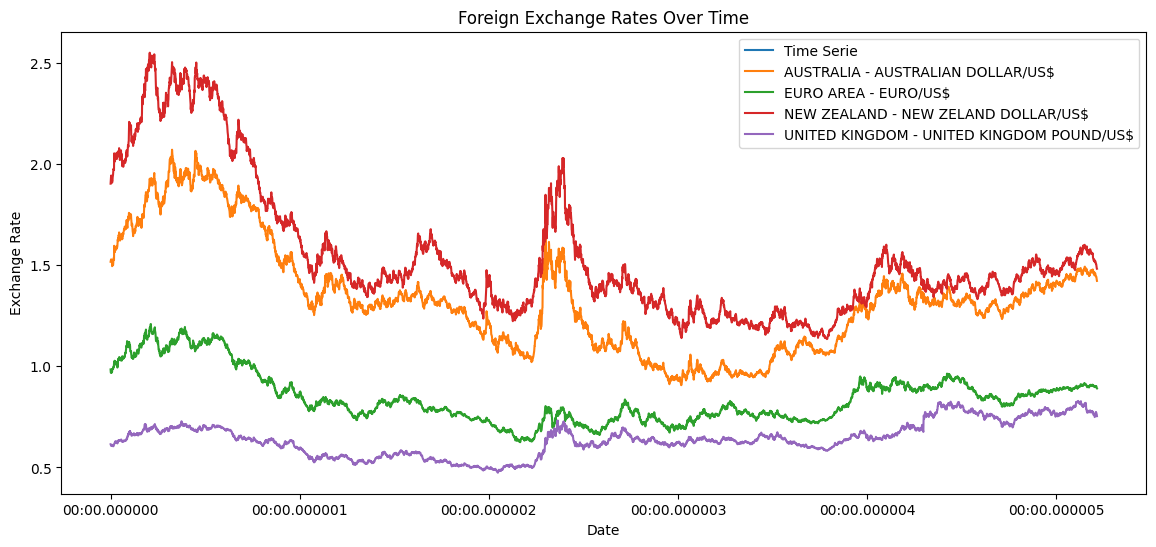

In [49]:
plt.figure(figsize=(14, 6))

for col in df.columns[1:6]:
    plt.plot(df["Date"], df[col], label=col)

plt.title("Foreign Exchange Rates Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

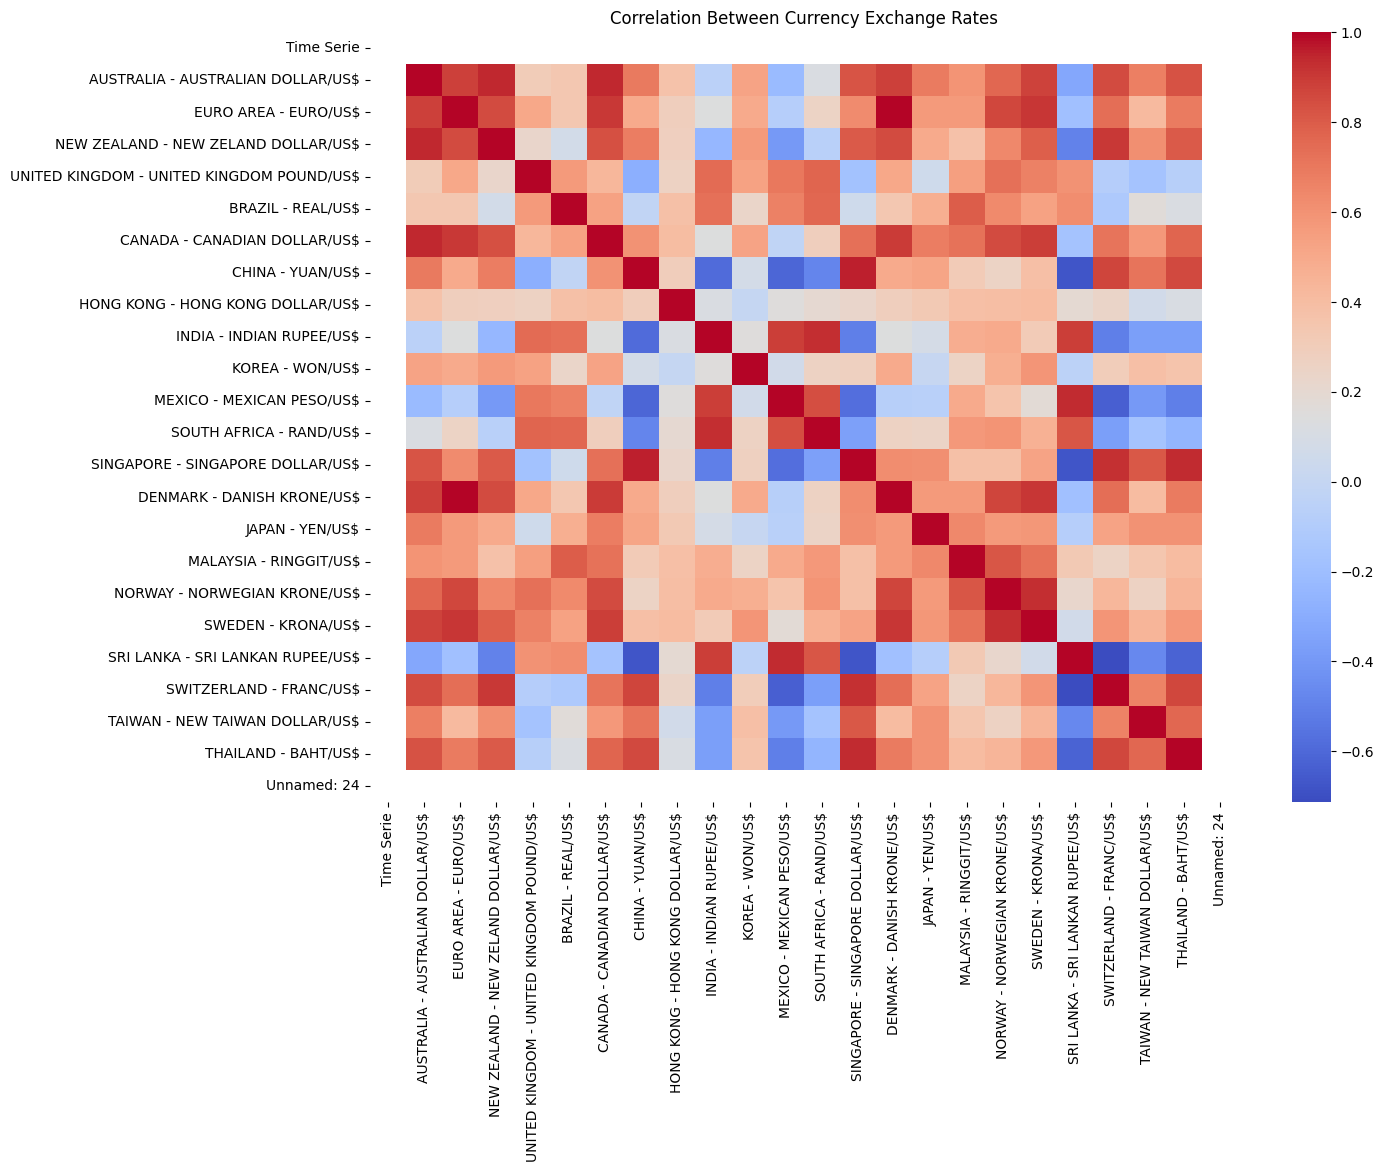

In [50]:
plt.figure(figsize=(14, 10))

corr = df.drop(columns="Date").corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlation Between Currency Exchange Rates")
plt.show()

In [51]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_percent

Time Serie                                   100.0
Unnamed: 24                                  100.0
Date                                           0.0
EURO AREA - EURO/US$                           0.0
AUSTRALIA - AUSTRALIAN DOLLAR/US$              0.0
UNITED KINGDOM - UNITED KINGDOM POUND/US$      0.0
BRAZIL - REAL/US$                              0.0
CANADA - CANADIAN DOLLAR/US$                   0.0
NEW ZEALAND - NEW ZELAND DOLLAR/US$            0.0
CHINA - YUAN/US$                               0.0
HONG KONG - HONG KONG DOLLAR/US$               0.0
KOREA - WON/US$                                0.0
INDIA - INDIAN RUPEE/US$                       0.0
SOUTH AFRICA - RAND/US$                        0.0
SINGAPORE - SINGAPORE DOLLAR/US$               0.0
DENMARK - DANISH KRONE/US$                     0.0
MEXICO - MEXICAN PESO/US$                      0.0
JAPAN - YEN/US$                                0.0
MALAYSIA - RINGGIT/US$                         0.0
SWEDEN - KRONA/US$             

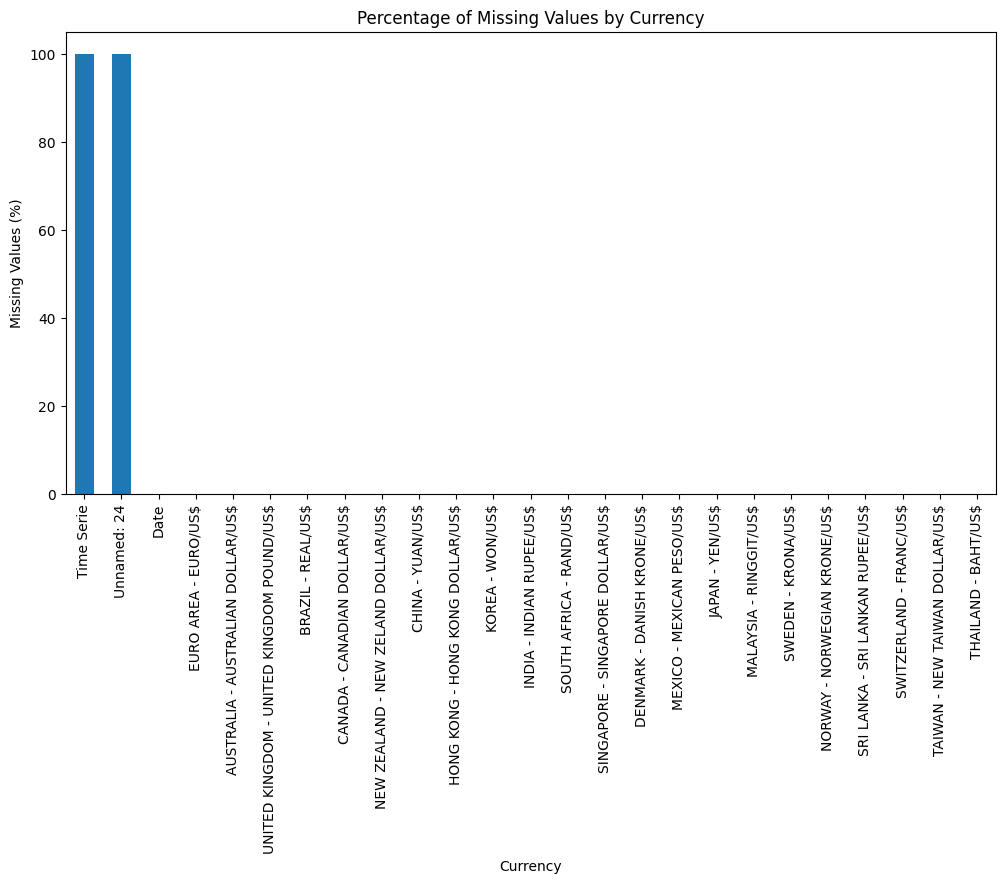

In [52]:
plt.figure(figsize=(12, 6))

missing_percent.plot(kind="bar")

plt.title("Percentage of Missing Values by Currency")
plt.xlabel("Currency")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.show()

In [56]:
def create_features(data, target_col):
    temp = data[["Date", target_col]].copy()
    temp = temp.dropna()

    temp["day"] = temp["Date"].dt.day
    temp["month"] = temp["Date"].dt.month
    temp["year"] = temp["Date"].dt.year
    temp["dayofweek"] = temp["Date"].dt.dayofweek

    temp["lag_1"] = temp[target_col].shift(1)
    temp["lag_7"] = temp[target_col].shift(7)
    temp["lag_30"] = temp[target_col].shift(30)

    temp["rolling_7"] = temp[target_col].rolling(window=7).mean()
    temp["rolling_30"] = temp[target_col].rolling(window=30).mean()

    temp = temp.dropna()

    X = temp.drop(columns=["Date", target_col])
    y = temp[target_col]

    return X, y, temp

In [57]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

In [1]:
import os

os.makedirs("models", exist_ok=True)

results = []

# Get all columns except 'Date'
all_data_columns = df.columns.drop("Date")

# Filter out columns that are entirely NaN, as they cannot be used for modeling
currency_columns = [col for col in all_data_columns if not df[col].isnull().all()]

for currency in currency_columns:
    print(f"Training models for: {currency}")

    X, y, temp = create_features(df, currency)

    # After create_features, ensure X and y are not empty (e.g., if there were NaNs that made all rows drop)
    if X.empty or y.empty:
        print(f"Skipping {currency} because create_features resulted in empty X or y after dropping NaNs.")
        continue

    test_size = 60

    # Ensure there's enough data for training and testing after feature creation
    if len(X) < test_size:
        print(f"Skipping {currency} due to insufficient data (less than test_size {test_size}) after feature creation.")
        continue

    X_train = X.iloc[:-test_size]
    X_test = X.iloc[-test_size:]

    y_train = y.iloc[:-test_size]
    y_test = y.iloc[-test_size:]

    # It's also good practice to ensure training sets are not empty, though the above checks should largely cover this
    if X_train.empty or y_train.empty:
        print(f"Skipping {currency} as training data is empty after split.")
        continue

    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )
    }

    best_model = None
    best_model_name = None
    best_rmse = float("inf")

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mae, rmse, mape = evaluate_model(y_test, preds)

        results.append({
            "Currency": currency,
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_model_name = model_name

    safe_currency_name = currency.replace("/", "_").replace(" ", "_")
    model_path = f"models/{safe_currency_name}_model.pkl"

    joblib.dump({
        "model": best_model,
        "currency": currency,
        "model_name": best_model_name,
        "last_data": temp.tail(30)
    }, model_path)

    print(f"Saved best model for {currency}: {best_model_name}")

NameError: name 'df' is not defined

In [59]:
results_df = pd.DataFrame(results)

results_df.sort_values(["Currency", "RMSE"]).head(20)

,Currency,Model,MAE,RMSE,MAPE
0,AUSTRALIA - AUSTRALIAN DOLLAR/US$,RandomForest,0.005039,0.006103,0.344840
1,AUSTRALIA - AUSTRALIAN DOLLAR/US$,XGBoost,0.005023,0.006407,0.344310
8,BRAZIL - REAL/US$,RandomForest,0.036825,0.047884,0.887622
9,BRAZIL - REAL/US$,XGBoost,0.050685,0.060284,1.223242
11,CANADA - CANADIAN DOLLAR/US$,XGBoost,0.002892,0.003998,0.219619
10,CANADA - CANADIAN DOLLAR/US$,RandomForest,0.003028,0.004152,0.229811
12,CHINA - YUAN/US$,RandomForest,0.009008,0.012746,0.128270
13,CHINA - YUAN/US$,XGBoost,0.010167,0.013431,0.144678
27,DENMARK - DANISH KRONE/US$,XGBoost,0.014869,0.019053,0.220672
26,DENMARK - DANISH KRONE/US$,RandomForest,0.019616,0.023337,0.291071


In [60]:
results_df.to_csv("model_results.csv", index=False)

In [61]:
def forecast_future(model_package, horizon=30):
    model = model_package["model"]
    currency = model_package["currency"]
    history = model_package["last_data"].copy()

    forecasts = []

    for i in range(horizon):
        next_date = history["Date"].max() + pd.Timedelta(days=1)

        row = {
            "day": next_date.day,
            "month": next_date.month,
            "year": next_date.year,
            "dayofweek": next_date.dayofweek,
            "lag_1": history[currency].iloc[-1],
            "lag_7": history[currency].iloc[-7],
            "lag_30": history[currency].iloc[-30],
            "rolling_7": history[currency].tail(7).mean(),
            "rolling_30": history[currency].tail(30).mean()
        }

        X_future = pd.DataFrame([row])

        prediction = model.predict(X_future)[0]

        forecasts.append({
            "Date": next_date,
            "Forecast": prediction
        })

        new_row = {
            "Date": next_date,
            currency: prediction
        }

        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    return pd.DataFrame(forecasts)

In [62]:
model_files = os.listdir("models")

model_files[:5]

['AUSTRALIA_-_AUSTRALIAN_DOLLAR_US$_model.pkl',
 'BRAZIL_-_REAL_US$_model.pkl',
 'CANADA_-_CANADIAN_DOLLAR_US$_model.pkl',
 'CHINA_-_YUAN_US$_model.pkl',
 'DENMARK_-_DANISH_KRONE_US$_model.pkl']

In [63]:
test_model_path = "models/" + model_files[0]

model_package = joblib.load(test_model_path)

forecast_df = forecast_future(model_package, horizon=30)

forecast_df.head()

,Date,Forecast
0,1970-01-02 00:00:00.000005216,1.432290
1,1970-01-03 00:00:00.000005216,1.431310
2,1970-01-04 00:00:00.000005216,1.427897
3,1970-01-05 00:00:00.000005216,1.425848
4,1970-01-06 00:00:00.000005216,1.423701


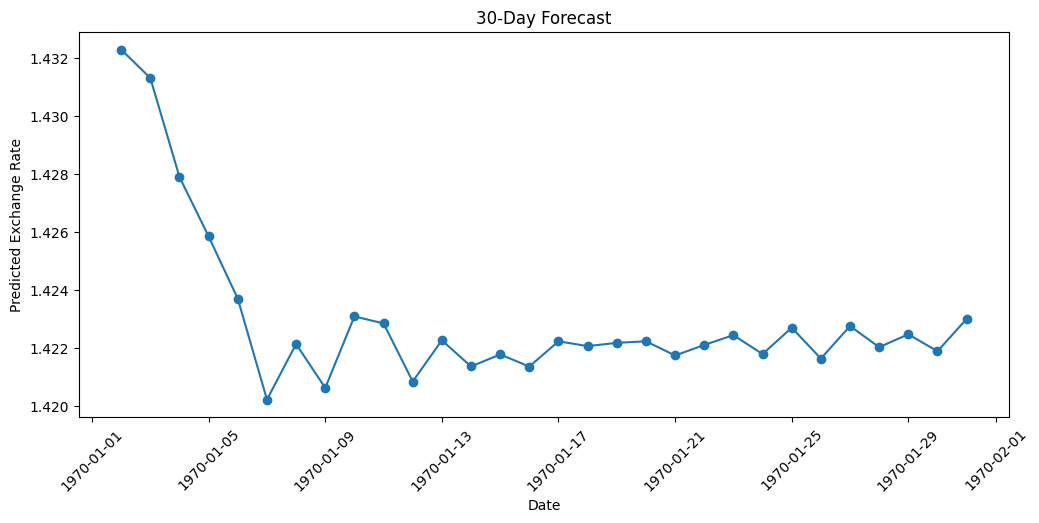

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(forecast_df["Date"], forecast_df["Forecast"], marker="o")

plt.title("30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Exchange Rate")
plt.xticks(rotation=45)
plt.show()